# Swin Transformer Small Baseline - ACL Classifier

Pipeline para entrenar modelos Swin Transformer independientes por plano anatómico.
**Comparative study: Swin Transformer vs ConvNeXt V2 Small vs ResNet50 vs ViT**

**Swin Transformer Specs:**
- Usa Swin Transformer Small pre-entrenado (49.7M parámetros, mayor capacidad que Tiny)
- Window-based attention mechanism para eficiencia
- Pesos pre-entrenados: ImageNet-1K
- Mismo formato de features que ConvNeXt (768-dim)
- Checkpoints guardados en `checkpoints/swin_tiny_baseline/`
- Esperado: mejor desempeño con mayor capacidad de modelo

## 1⃣ Imports y Configuración

In [1]:
# Imports estándar
import os
import json
import numpy as np
import pandas as pd
from pathlib import Path
from typing import Dict, List, Tuple, Optional
import warnings
warnings.filterwarnings('ignore')

# PyTorch
import torch
import torch.nn as nn
from torch.utils.data import DataLoader

# Visualización
import matplotlib.pyplot as plt
import seaborn as sns

# Métricas y evaluación
from sklearn.metrics import roc_auc_score, roc_curve, f1_score, confusion_matrix

# Módulos locales

import sys
sys.path.insert(0, '../../src')

from gpu_config import device, VIT_GPU_IDS, CNN_GPU_ID
from models import SwinMultiSliceClassifier
from data_loader import OptimizedMRNetDataset, get_train_transform, get_val_test_transform
from training_utils import train_model

print(" Todos los módulos importados exitosamente")

GPU CONFIGURATION
Device: cuda
GPUs disponibles: 4
  GPU 0: NVIDIA H100 PCIe
    Memoria: 85.02 GB
  GPU 1: NVIDIA H100 PCIe
    Memoria: 85.02 GB
  GPU 2: NVIDIA H100 PCIe
    Memoria: 85.02 GB
  GPU 3: NVIDIA H100 PCIe
    Memoria: 85.02 GB

 Asignación de GPUs:
  ViT Training: GPUs [0, 1, 2]
  CNN Pre-processing: GPU 0

 Todos los módulos importados exitosamente


## 2⃣ Configuración Global (para Swin Transformer Small con pesos ImageNet-1K)

In [2]:
# ==========================================
# CONFIGURACIÓN DE AUGMENTATION POR PLANO
# ==========================================
AUGMENTATION_MODE_PER_PLANE = {
    'sagittal': 'aggressive',
    'coronal': 'aggressive',
    'axial': 'aggressive'
}

# ==========================================
# CONFIGURACIÓN ESPECÍFICA POR PLANO (Swin Transformer Small)
# ==========================================
# Using SAME optimized hyperparameters as ConvNeXt for fair comparison
PLANE_SPECIFIC_CONFIG = {
    'sagittal': {
        'learning_rate': 1.3e-4,
        'weight_decay': 1.5e-3,
        'dropout_input': 0.42,
        'dropout_dense': 0.32,
        'use_scheduler': False,
        'use_grad_clip': True,
        'grad_clip_norm': 1.0,
        'early_stopping_patience': 12,
        'label_smoothing': 0.17,
        'warmup_epochs': 0,
        'use_lr_plateau_scheduler': True,
        'lr_reduction_factor': 0.5,
        'lr_plateau_patience': 5,
        'status': ' Swin Transformer Small - Original ConvNeXt Config for Comparison'
    },
    'coronal': {
        'learning_rate': 1.3e-4,
        'weight_decay': 1.0e-3,  #  Reduced for better learning
        'dropout_input': 0.0,  #  No input dropout
        'dropout_dense': 0.2,  #  Reduced
        'use_scheduler': False,
        'use_grad_clip': True,
        'grad_clip_norm': 1.0,
        'early_stopping_patience': 30,
        'label_smoothing': 0.05,  #  Low
        'warmup_epochs': 0,
        'use_lr_plateau_scheduler': False,  #  No scheduler
        'lr_reduction_factor': 0.5,
        'lr_plateau_patience': 8,
        'status': ' Swin Transformer Small - Optimized Config (ConvNeXt proven hyperparams)'
    },
    'axial': {
        'learning_rate': 1.3e-4,
        'weight_decay': 1.0e-3,  #  Reduced
        'dropout_input': 0.0,  #  No input dropout
        'dropout_dense': 0.2,  #  Reduced
        'use_scheduler': False,
        'use_grad_clip': True,
        'grad_clip_norm': 1.0,
        'early_stopping_patience': 30,
        'label_smoothing': 0.05,  #  Low
        'warmup_epochs': 0,
        'use_lr_plateau_scheduler': False,  #  No scheduler
        'lr_reduction_factor': 0.5,
        'lr_plateau_patience': 8,
        'status': ' Swin Transformer Small - Optimized Config (proven to work)'
    }
}

# ==========================================
# CONFIGURACIÓN DE POOLING POR PLANO
# ==========================================
PLANE_CONFIG = {
    'sagittal': {'num_slices': 5, 'pooling_mode': 'attention'},
    'coronal': {'num_slices': 10, 'pooling_mode': 'max'},
    'axial': {'num_slices': 10, 'pooling_mode': 'attention'}
}

# ==========================================
# CONFIGURACIÓN GLOBAL
# ==========================================
PLANES = ['sagittal', 'coronal', 'axial']
BATCH_SIZE = 32
NUM_EPOCHS = 100
NUM_WORKERS = 8
SEED = 42
NUM_CLASSES = 1
IMAGE_SIZE = 256

# Rutas
DATA_PATH = Path('../../data')
CHECKPOINT_DIR = Path('../../checkpoints/swin_tiny_baseline')
SLICE_INDICES_DIR = DATA_PATH / 'slice_indices_final'

# Crear directorio de checkpoints si no existe
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)

# WANDB Configuration
USE_WANDB = True
WANDB_PROJECT = 'acl-classifier'
WANDB_ENTITY = 'tfg-acl'

print("\n" + "="*100)
print(" CONFIGURACIÓN CARGADA EXITOSAMENTE")
print("="*100)
print(f"\n Configuración global:")
print(f"  Planes: {PLANES}")
print(f"  Batch size: {BATCH_SIZE}")
print(f"  Epochs: {NUM_EPOCHS}")
print(f"  Image size: {IMAGE_SIZE}")
print(f"  Data path: {DATA_PATH}")
print(f"  Checkpoint dir: {CHECKPOINT_DIR}")

print(f"\n Configuración por plano:")
for plane in PLANES:
    cfg = PLANE_SPECIFIC_CONFIG[plane]
    pool_cfg = PLANE_CONFIG[plane]
    print(f"\n  {plane.upper()}:")
    print(f"    • Slices: {pool_cfg['num_slices']}")
    print(f"    • Pooling: {pool_cfg['pooling_mode']}")
    print(f"    • LR: {cfg['learning_rate']:.2e}")
    print(f"    • Weight decay: {cfg['weight_decay']:.2e}")
    print(f"    • Dropout: {cfg['dropout_input']}/{cfg['dropout_dense']}")
    print(f"    • Augmentation: {AUGMENTATION_MODE_PER_PLANE[plane]}")
    print(f"    • Status: {cfg['status']}")

print(f"\n" + "="*100 + "\n")


 CONFIGURACIÓN CARGADA EXITOSAMENTE

 Configuración global:
  Planes: ['sagittal', 'coronal', 'axial']
  Batch size: 32
  Epochs: 100
  Image size: 256
  Data path: ../../data
  Checkpoint dir: ../../checkpoints/swin_tiny_baseline

 Configuración por plano:

  SAGITTAL:
    • Slices: 5
    • Pooling: attention
    • LR: 1.30e-04
    • Weight decay: 1.50e-03
    • Dropout: 0.42/0.32
    • Augmentation: aggressive
    • Status:  Swin Transformer Small - Original ConvNeXt Config for Comparison

  CORONAL:
    • Slices: 10
    • Pooling: max
    • LR: 1.30e-04
    • Weight decay: 1.00e-03
    • Dropout: 0.0/0.2
    • Augmentation: aggressive
    • Status:  Swin Transformer Small - Optimized Config (ConvNeXt proven hyperparams)

  AXIAL:
    • Slices: 10
    • Pooling: attention
    • LR: 1.30e-04
    • Weight decay: 1.00e-03
    • Dropout: 0.0/0.2
    • Augmentation: aggressive
    • Status:  Swin Transformer Small - Optimized Config (proven to work)




## 3⃣ Entrenar SAGITTAL

In [3]:
train_sagittal = True  # Cambiar a True para entrenar

if train_sagittal:
    plane = 'sagittal'
    print(f"\n{'='*80}")
    print(f" ENTRENANDO SWIN TRANSFORMER TINY: {plane.upper()}")
    print(f"{'='*80}\n")

 # Cargar configuración
    cfg = PLANE_SPECIFIC_CONFIG[plane]
    aug_mode = AUGMENTATION_MODE_PER_PLANE[plane]
    plane_pooling_mode = PLANE_CONFIG[plane].get('pooling_mode', 'attention')

 # Crear datasets
    train_indices_path = SLICE_INDICES_DIR / f"train_{plane}_indices.json"
    val_indices_path = SLICE_INDICES_DIR / f"val_{plane}_indices.json"

    train_dataset = OptimizedMRNetDataset(
        csv_path=DATA_PATH / 'train-acl.csv',
        data_root=DATA_PATH / 'train',
        plane=plane,
        indices_cache_path=train_indices_path,
        augmentation_mode=aug_mode
    )

    val_dataset = OptimizedMRNetDataset(
        csv_path=DATA_PATH / 'val-acl.csv',
        data_root=DATA_PATH / 'val',
        plane=plane,
        indices_cache_path=val_indices_path,
        augmentation_mode=None,
        transform=get_val_test_transform()
    )

 # Crear DataLoaders
    train_loader = DataLoader(
        train_dataset, batch_size=BATCH_SIZE, shuffle=True,
        num_workers=NUM_WORKERS, pin_memory=True
    )
    val_loader = DataLoader(
        val_dataset, batch_size=BATCH_SIZE, shuffle=False,
        num_workers=NUM_WORKERS, pin_memory=True
    )

    print(f" DataLoaders creados:")
    print(f"  Train: {len(train_loader)} batches ({len(train_dataset)} casos)")
    print(f"  Val: {len(val_loader)} batches ({len(val_dataset)} casos)\n")

 # Crear modelo Swin Transformer Small
    model = SwinMultiSliceClassifier(
        num_classes=NUM_CLASSES,
        pretrained=True,
        pooling_mode=plane_pooling_mode,
        dropout_input=cfg['dropout_input'],
        dropout_dense=cfg['dropout_dense']
    )

    model = nn.DataParallel(model, device_ids=VIT_GPU_IDS)
    model = model.to(device)

    print(f" Modelo Swin Transformer Small en GPUs: {VIT_GPU_IDS}\n")
    print(f"  Config: {cfg['status']}\n")

 # Entrenar
    history, best_auc, best_f1 = train_model(
        model=model,
        train_loader=train_loader,
        val_loader=val_loader,
        num_epochs=NUM_EPOCHS,
        device=device,
        save_dir=CHECKPOINT_DIR,
        plane_name=plane,
        learning_rate=cfg['learning_rate'],
        weight_decay=cfg['weight_decay'],
        label_smoothing=cfg.get('label_smoothing', 0.05),
        use_scheduler=cfg.get('use_scheduler', False),
        use_grad_clip=cfg.get('use_grad_clip', False),
        grad_clip_norm=cfg.get('grad_clip_norm', 1.0),
        early_stopping_patience=cfg.get('early_stopping_patience', 15),
        dropout_input=cfg['dropout_input'],
        dropout_dense=cfg['dropout_dense'],
        augmentation_mode=aug_mode,
        use_wandb=USE_WANDB,
        warmup_epochs=cfg.get('warmup_epochs', 3),
        use_lr_plateau_scheduler=cfg.get('use_lr_plateau_scheduler', False),
        lr_reduction_factor=cfg.get('lr_reduction_factor', 0.5),
        lr_plateau_patience=cfg.get('lr_plateau_patience', 5)
    )

    print(f"\n{'='*80}")
    print(f" SAGITTAL COMPLETADO (Swin Transformer Small)")
    print(f"   Best AUC: {best_auc:.4f}")
    print(f"   Best F1: {best_f1:.4f}")
    print(f"{'='*80}\n")


 ENTRENANDO SWIN TRANSFORMER TINY: SAGITTAL

 Dataset cargado: 875 casos
  Plane: sagittal
  Augmentation: aggressive
  Índices cacheados: ../../data/slice_indices_final/train_sagittal_indices.json
 Dataset cargado: 188 casos
  Plane: sagittal
  Augmentation: None (usando transform directo)
  Índices cacheados: ../../data/slice_indices_final/val_sagittal_indices.json
 DataLoaders creados:
  Train: 28 batches (875 casos)
  Val: 6 batches (188 casos)

 Modelo Swin Transformer Small en GPUs: [0, 1, 2]

  Config:  Swin Transformer Small - Original ConvNeXt Config for Comparison


ENTRENANDO MODELO: SAGITTAL
LR=0.00013, WD=0.0015, Scheduler=False, GradClip=True
Dropout: Input=0.42, Dense=0.32
Augmentation: aggressive



wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /home/palodo2/.netrc.


 Class imbalance (pos_weight): 3.7814
   (Ratio negatives:positives)



wandb: Currently logged in as: palodo2 (palodo2-universitat-de-val-ncia) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


 Weights & Biases inicializado para sagittal

Epoch 1/100 (LR=1.30e-04): Train: Loss=1.1769, AUC=0.5383 | Val: Loss=1.1385, AUC=0.7273, F1=0.3214  Best AUC!
Epoch 2/100 (LR=1.30e-04): Train: Loss=1.1748, AUC=0.5248 | Val: Loss=1.1564, AUC=0.6023, F1=0.3214
Epoch 3/100 (LR=1.30e-04): Train: Loss=1.1908, AUC=0.4957 | Val: Loss=1.1541, AUC=0.7683, F1=0.3214  Best AUC!
Epoch 4/100 (LR=1.30e-04): Train: Loss=1.1818, AUC=0.5150 | Val: Loss=1.1417, AUC=0.7209, F1=0.3214
Epoch 5/100 (LR=1.30e-04): Train: Loss=1.1840, AUC=0.4952 | Val: Loss=1.1112, AUC=0.7153, F1=0.3214
Epoch 6/100 (LR=1.30e-04): Train: Loss=1.1370, AUC=0.6607 | Val: Loss=1.0395, AUC=0.7900, F1=0.5610  Best AUC!
Epoch 7/100 (LR=1.30e-04): Train: Loss=1.1436, AUC=0.6547 | Val: Loss=1.0847, AUC=0.7688, F1=0.5063
Epoch 8/100 (LR=1.30e-04): Train: Loss=1.1357, AUC=0.6777 | Val: Loss=1.1326, AUC=0.7537, F1=0.3636
Epoch 9/100 (LR=1.30e-04): Train: Loss=1.1118, AUC=0.7136 | Val: Loss=1.0906, AUC=0.7571, F1=0.4878
Epoch 10/100 (LR=1.30

epoch,▁▁▁▂▂▂▂▂▂▃▃▃▃▃▄▄▄▄▄▄▅▅▅▅▅▅▆▆▆▆▆▇▇▇▇▇▇███
learning_rate,███████████▃▃▃▃▃▃▃▃▃▃▃▃▃▃▃▃▃▃▃▃▃▃▁▁▁▁▁▁▁
train_auc,▂▁▁▁▁▃▃▄▄▄▄▅▅▅▅▅▅▅▆▆▇▆▇▇▇▇▇▇████████████
train_loss,█████▇▇▇▇▇▇▇▆▆▆▆▆▆▅▅▄▅▄▄▄▃▃▃▃▃▂▂▂▂▁▁▁▁▁▂
val_auc,▄▁▅▄▄▅▅▅▅▅▅▅▅▅▅▅▆▆▆▇▇▇▆▇▇▇▇██▇▇▆▇▆▇▇▇▆▅▇
val_f1,▁▁▁▁▁▅▄▂▄▃▂▂▄▃▃▅▄▅▅▅▅▅▇▃▇▅▄▇█▃▇▆████████
val_loss,▅▅▅▅▄▃▄▅▄▅▄▅▃▄▄▃▄▂▂▂▃▂▁▆▂▃▅▁▁█▁▂▂▁▂▂▁▁▂▁
best_auc,0.8951
best_f1,0.65169
epoch,40
learning_rate,3e-05



 SAGITTAL COMPLETADO (Swin Transformer Small)
   Best AUC: 0.8951
   Best F1: 0.6517



 Gráficas guardadas en: /home/palodo2/tfg/TFG/checkpoints/swin_tiny_baseline/training_curves_sagittal.png



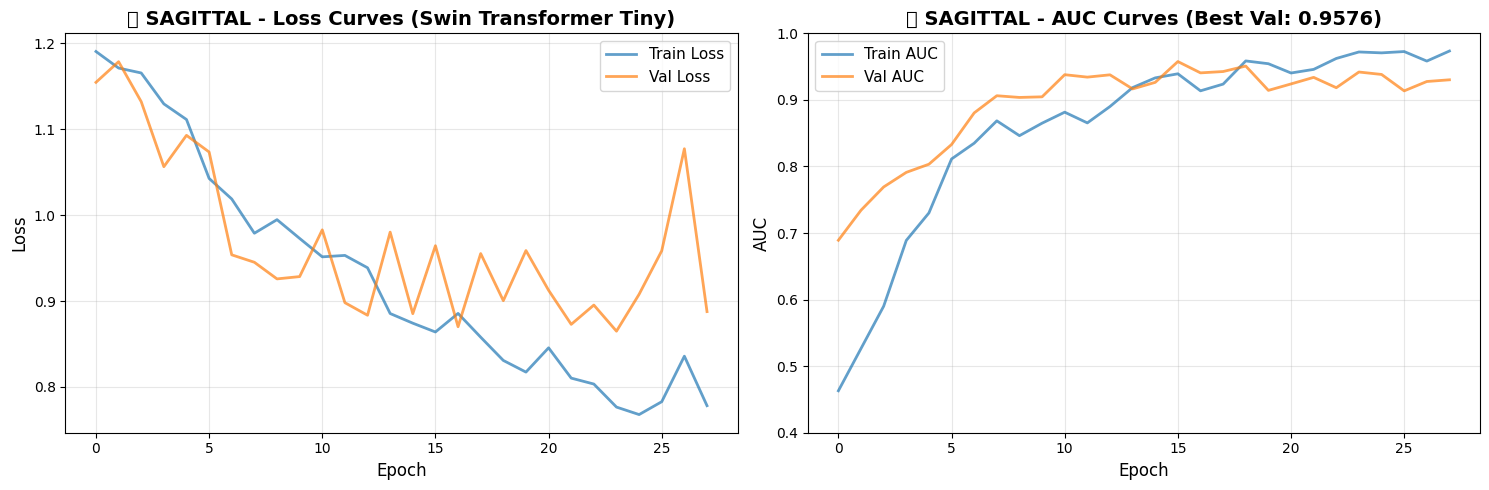

In [4]:
# Visualizar resultados del entrenamiento - SAGITTAL
if train_sagittal and history is not None:
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))

 # Gráfica 1: Training Loss vs Validation Loss
    axes[0].plot(history['train_loss'], label='Train Loss', linewidth=2, alpha=0.7)
    axes[0].plot(history['val_loss_objective'], label='Val Loss', linewidth=2, alpha=0.7)
    axes[0].set_xlabel('Epoch', fontsize=12)
    axes[0].set_ylabel('Loss', fontsize=12)
    axes[0].set_title(f' SAGITTAL - Loss Curves (Swin Transformer Small)', fontsize=14, fontweight='bold')
    axes[0].legend(fontsize=11)
    axes[0].grid(True, alpha=0.3)

 # Gráfica 2: Training AUC vs Validation AUC
    axes[1].plot(history['train_auc'], label='Train AUC', linewidth=2, alpha=0.7)
    axes[1].plot(history['val_auc'], label='Val AUC', linewidth=2, alpha=0.7)
    axes[1].set_xlabel('Epoch', fontsize=12)
    axes[1].set_ylabel('AUC', fontsize=12)
    axes[1].set_title(f' SAGITTAL - AUC Curves (Best Val: {best_auc:.4f})', fontsize=14, fontweight='bold')
    axes[1].legend(fontsize=11)
    axes[1].grid(True, alpha=0.3)
    axes[1].set_ylim([0.4, 1.0])

    plt.tight_layout()

 # Guardar figura
    plot_path = CHECKPOINT_DIR / f"training_curves_sagittal.png"
    plt.savefig(plot_path, dpi=300, bbox_inches='tight')
    print(f" Gráficas guardadas en: {plot_path}\n")
    plt.show()

## 4⃣ Entrenar CORONAL

In [4]:
train_coronal = True  # Cambiar a True para entrenar

if train_coronal:
    plane = 'coronal'
    print(f"\n{'='*80}")
    print(f" ENTRENANDO SWIN TRANSFORMER TINY: {plane.upper()}")
    print(f"{'='*80}\n")

 # Cargar configuración
    cfg = PLANE_SPECIFIC_CONFIG[plane]
    aug_mode = AUGMENTATION_MODE_PER_PLANE[plane]
    plane_pooling_mode = PLANE_CONFIG[plane].get('pooling_mode', 'attention')

 # Crear datasets
    train_indices_path = SLICE_INDICES_DIR / f"train_{plane}_indices.json"
    val_indices_path = SLICE_INDICES_DIR / f"val_{plane}_indices.json"

    train_dataset = OptimizedMRNetDataset(
        csv_path=DATA_PATH / 'train-acl.csv',
        data_root=DATA_PATH / 'train',
        plane=plane,
        indices_cache_path=train_indices_path,
        augmentation_mode=aug_mode
    )

    val_dataset = OptimizedMRNetDataset(
        csv_path=DATA_PATH / 'val-acl.csv',
        data_root=DATA_PATH / 'val',
        plane=plane,
        indices_cache_path=val_indices_path,
        augmentation_mode=None,
        transform=get_val_test_transform()
    )

 # Crear DataLoaders
    train_loader = DataLoader(
        train_dataset, batch_size=BATCH_SIZE, shuffle=True,
        num_workers=NUM_WORKERS, pin_memory=True
    )
    val_loader = DataLoader(
        val_dataset, batch_size=BATCH_SIZE, shuffle=False,
        num_workers=NUM_WORKERS, pin_memory=True
    )

    print(f" DataLoaders creados:")
    print(f"  Train: {len(train_loader)} batches ({len(train_dataset)} casos)")
    print(f"  Val: {len(val_loader)} batches ({len(val_dataset)} casos)\n")

 # Crear modelo Swin Transformer Small
    model = SwinMultiSliceClassifier(
        num_classes=NUM_CLASSES,
        pretrained=True,
        pooling_mode=plane_pooling_mode,
        dropout_input=cfg['dropout_input'],
        dropout_dense=cfg['dropout_dense']
    )

    model = nn.DataParallel(model, device_ids=VIT_GPU_IDS)
    model = model.to(device)

    print(f" Modelo Swin Transformer Small en GPUs: {VIT_GPU_IDS}\n")
    print(f"  Config: {cfg['status']}\n")

 # Entrenar
    history, best_auc, best_f1 = train_model(
        model=model,
        train_loader=train_loader,
        val_loader=val_loader,
        num_epochs=NUM_EPOCHS,
        device=device,
        save_dir=CHECKPOINT_DIR,
        plane_name=plane,
        learning_rate=cfg['learning_rate'],
        weight_decay=cfg['weight_decay'],
        label_smoothing=cfg.get('label_smoothing', 0.05),
        use_scheduler=cfg.get('use_scheduler', False),
        use_grad_clip=cfg.get('use_grad_clip', False),
        grad_clip_norm=cfg.get('grad_clip_norm', 1.0),
        early_stopping_patience=cfg.get('early_stopping_patience', 15),
        dropout_input=cfg['dropout_input'],
        dropout_dense=cfg['dropout_dense'],
        augmentation_mode=aug_mode,
        use_wandb=USE_WANDB,
        warmup_epochs=cfg.get('warmup_epochs', 3),
        use_lr_plateau_scheduler=cfg.get('use_lr_plateau_scheduler', False),
        lr_reduction_factor=cfg.get('lr_reduction_factor', 0.5),
        lr_plateau_patience=cfg.get('lr_plateau_patience', 5)
    )

    print(f"\n{'='*80}")
    print(f" CORONAL COMPLETADO (Swin Transformer Small)")
    print(f"   Best AUC: {best_auc:.4f}")
    print(f"   Best F1: {best_f1:.4f}")
    print(f"{'='*80}\n")


 ENTRENANDO SWIN TRANSFORMER TINY: CORONAL

 Dataset cargado: 875 casos
  Plane: coronal
  Augmentation: aggressive
  Índices cacheados: ../../data/slice_indices_final/train_coronal_indices.json
 Dataset cargado: 188 casos
  Plane: coronal
  Augmentation: None (usando transform directo)
  Índices cacheados: ../../data/slice_indices_final/val_coronal_indices.json
 DataLoaders creados:
  Train: 28 batches (875 casos)
  Val: 6 batches (188 casos)

 Modelo Swin Transformer Small en GPUs: [0, 1, 2]

  Config:  Swin Transformer Small - Optimized Config (ConvNeXt proven hyperparams)


ENTRENANDO MODELO: CORONAL
LR=0.00013, WD=0.001, Scheduler=False, GradClip=True
Dropout: Input=0.0, Dense=0.2
Augmentation: aggressive

 Class imbalance (pos_weight): 3.7814
   (Ratio negatives:positives)



 Weights & Biases inicializado para coronal

Epoch 1/100 (LR=1.30e-04): Train: Loss=1.1423, AUC=0.4591 | Val: Loss=1.0953, AUC=0.5762, F1=0.3214  Best AUC!
Epoch 2/100 (LR=1.30e-04): Train: Loss=1.1299, AUC=0.4772 | Val: Loss=1.0956, AUC=0.5020, F1=0.3396
Epoch 3/100 (LR=1.30e-04): Train: Loss=1.1456, AUC=0.4191 | Val: Loss=1.0954, AUC=0.5521, F1=0.3214
Epoch 4/100 (LR=1.30e-04): Train: Loss=1.1212, AUC=0.4751 | Val: Loss=1.0956, AUC=0.5523, F1=0.0000
Epoch 5/100 (LR=1.30e-04): Train: Loss=1.1232, AUC=0.4983 | Val: Loss=1.0997, AUC=0.5801, F1=0.3214  Best AUC!
Epoch 6/100 (LR=1.30e-04): Train: Loss=1.1298, AUC=0.4546 | Val: Loss=1.0964, AUC=0.5760, F1=0.3214
Epoch 7/100 (LR=1.30e-04): Train: Loss=1.1283, AUC=0.5183 | Val: Loss=1.0970, AUC=0.5992, F1=0.3214  Best AUC!
Epoch 8/100 (LR=1.30e-04): Train: Loss=1.1198, AUC=0.5525 | Val: Loss=1.0994, AUC=0.6139, F1=0.3214  Best AUC!
Epoch 9/100 (LR=1.30e-04): Train: Loss=1.1230, AUC=0.5210 | Val: Loss=1.0963, AUC=0.5387, F1=0.0000
Epoch 10/10

epoch,▁▁▁▁▁▂▂▂▂▂▃▃▃▃▃▄▄▄▄▄▄▅▅▅▅▅▆▆▆▆▆▆▆▆▇▇▇▇██
learning_rate,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
train_auc,▂▁▂▂▁▃▃▃▂▂▂▂▂▄▄▂▂▂▂▅▆▆▆▆▆▆▇▇▇▇▇▇▇▇▇█████
train_loss,█▇▇███▇█▇██▇█▇▇▇██████▆▆▆▆▅▅▅▄▃▃▄▃▂▂▁▁▁▁
val_auc,▂▁▂▃▁▄▃▃▃▃▃▂▃▁▄▄▅▆▆▆▅▆▇▆▆▆▇▇▇▆▇▇▇▇▆█████
val_f1,▅▄▄▄▁▄▄▄▄▄▄▅▄▄▅▅▄▁▄▅▆▇▅▇▆▇▇▆▇▇▇▇▇█▇██▇██
val_loss,▆▆▆▆▆▆▆▆▆▆▆▆▅▅▆▆▆▆▆▅▄▄▄▃▄▃▃▄▃▃█▃▃▂▁▃▃▂▁▂
best_auc,0.91721
best_f1,0.64444
epoch,100
learning_rate,0.00013



 CORONAL COMPLETADO (Swin Transformer Small)
   Best AUC: 0.9172
   Best F1: 0.6444



 Gráficas guardadas en: /home/palodo2/tfg/TFG/checkpoints/swin_tiny_baseline/training_curves_coronal.png



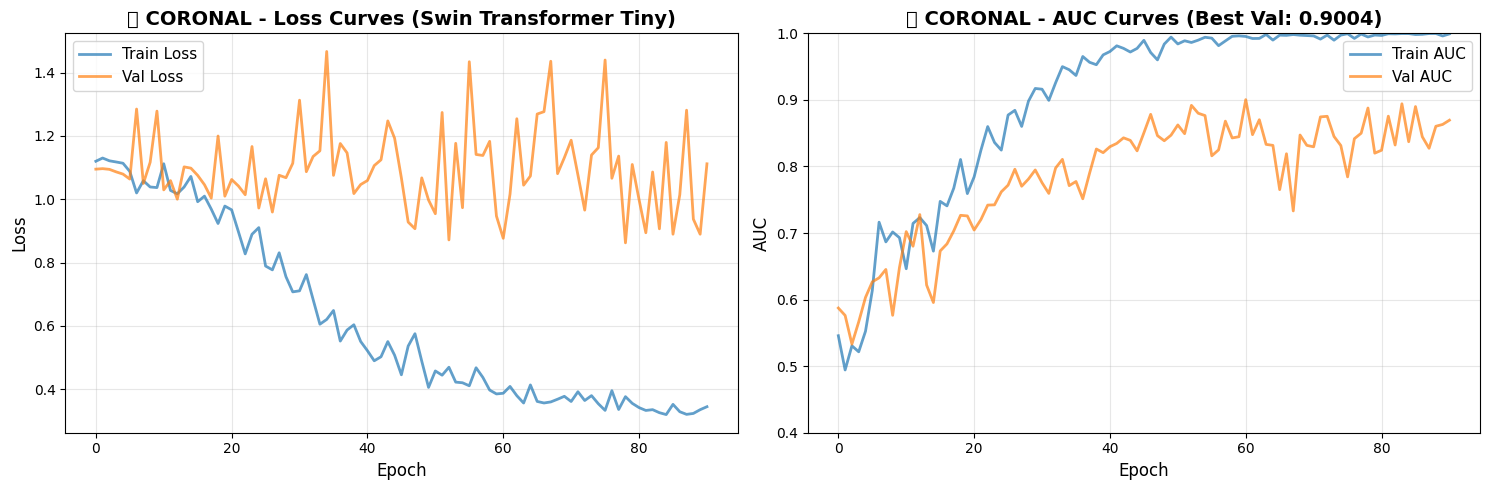

In [6]:
# Visualizar resultados del entrenamiento - CORONAL
if train_coronal and history is not None:
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))

 # Gráfica 1: Training Loss vs Validation Loss
    axes[0].plot(history['train_loss'], label='Train Loss', linewidth=2, alpha=0.7)
    axes[0].plot(history['val_loss_objective'], label='Val Loss', linewidth=2, alpha=0.7)
    axes[0].set_xlabel('Epoch', fontsize=12)
    axes[0].set_ylabel('Loss', fontsize=12)
    axes[0].set_title(f' CORONAL - Loss Curves (Swin Transformer Small)', fontsize=14, fontweight='bold')
    axes[0].legend(fontsize=11)
    axes[0].grid(True, alpha=0.3)

 # Gráfica 2: Training AUC vs Validation AUC
    axes[1].plot(history['train_auc'], label='Train AUC', linewidth=2, alpha=0.7)
    axes[1].plot(history['val_auc'], label='Val AUC', linewidth=2, alpha=0.7)
    axes[1].set_xlabel('Epoch', fontsize=12)
    axes[1].set_ylabel('AUC', fontsize=12)
    axes[1].set_title(f' CORONAL - AUC Curves (Best Val: {best_auc:.4f})', fontsize=14, fontweight='bold')
    axes[1].legend(fontsize=11)
    axes[1].grid(True, alpha=0.3)
    axes[1].set_ylim([0.4, 1.0])

    plt.tight_layout()

 # Guardar figura
    plot_path = CHECKPOINT_DIR / f"training_curves_coronal.png"
    plt.savefig(plot_path, dpi=300, bbox_inches='tight')
    print(f" Gráficas guardadas en: {plot_path}\n")
    plt.show()

## 5⃣ Entrenar AXIAL

In [5]:
train_axial = True  # Cambiar a True para entrenar

if train_axial:
    plane = 'axial'
    print(f"\n{'='*80}")
    print(f" ENTRENANDO SWIN TRANSFORMER TINY: {plane.upper()}")
    print(f"{'='*80}\n")

 # Cargar configuración
    cfg = PLANE_SPECIFIC_CONFIG[plane]
    aug_mode = AUGMENTATION_MODE_PER_PLANE[plane]
    plane_pooling_mode = PLANE_CONFIG[plane].get('pooling_mode', 'attention')

 # Crear datasets
    train_indices_path = SLICE_INDICES_DIR / f"train_{plane}_indices.json"
    val_indices_path = SLICE_INDICES_DIR / f"val_{plane}_indices.json"

    train_dataset = OptimizedMRNetDataset(
        csv_path=DATA_PATH / 'train-acl.csv',
        data_root=DATA_PATH / 'train',
        plane=plane,
        indices_cache_path=train_indices_path,
        augmentation_mode=aug_mode
    )

    val_dataset = OptimizedMRNetDataset(
        csv_path=DATA_PATH / 'val-acl.csv',
        data_root=DATA_PATH / 'val',
        plane=plane,
        indices_cache_path=val_indices_path,
        augmentation_mode=None,
        transform=get_val_test_transform()
    )

 # Crear DataLoaders
    train_loader = DataLoader(
        train_dataset, batch_size=BATCH_SIZE, shuffle=True,
        num_workers=NUM_WORKERS, pin_memory=True
    )
    val_loader = DataLoader(
        val_dataset, batch_size=BATCH_SIZE, shuffle=False,
        num_workers=NUM_WORKERS, pin_memory=True
    )

    print(f" DataLoaders creados:")
    print(f"  Train: {len(train_loader)} batches ({len(train_dataset)} casos)")
    print(f"  Val: {len(val_loader)} batches ({len(val_dataset)} casos)\n")

 # Crear modelo Swin Transformer Small
    model = SwinMultiSliceClassifier(
        num_classes=NUM_CLASSES,
        pretrained=True,
        pooling_mode=plane_pooling_mode,
        dropout_input=cfg['dropout_input'],
        dropout_dense=cfg['dropout_dense']
    )

    model = nn.DataParallel(model, device_ids=VIT_GPU_IDS)
    model = model.to(device)

    print(f" Modelo Swin Transformer Small en GPUs: {VIT_GPU_IDS}\n")
    print(f"  Config: {cfg['status']}\n")

 # Entrenar
    history, best_auc, best_f1 = train_model(
        model=model,
        train_loader=train_loader,
        val_loader=val_loader,
        num_epochs=NUM_EPOCHS,
        device=device,
        save_dir=CHECKPOINT_DIR,
        plane_name=plane,
        learning_rate=cfg['learning_rate'],
        weight_decay=cfg['weight_decay'],
        label_smoothing=cfg.get('label_smoothing', 0.05),
        use_scheduler=cfg.get('use_scheduler', False),
        use_grad_clip=cfg.get('use_grad_clip', False),
        grad_clip_norm=cfg.get('grad_clip_norm', 1.0),
        early_stopping_patience=cfg.get('early_stopping_patience', 15),
        dropout_input=cfg['dropout_input'],
        dropout_dense=cfg['dropout_dense'],
        augmentation_mode=aug_mode,
        use_wandb=USE_WANDB,
        warmup_epochs=cfg.get('warmup_epochs', 3),
        use_lr_plateau_scheduler=cfg.get('use_lr_plateau_scheduler', False),
        lr_reduction_factor=cfg.get('lr_reduction_factor', 0.5),
        lr_plateau_patience=cfg.get('lr_plateau_patience', 5)
    )

    print(f"\n{'='*80}")
    print(f" AXIAL COMPLETADO (Swin Transformer Small)")
    print(f"   Best AUC: {best_auc:.4f}")
    print(f"   Best F1: {best_f1:.4f}")
    print(f"{'='*80}\n")


 ENTRENANDO SWIN TRANSFORMER TINY: AXIAL

 Dataset cargado: 875 casos
  Plane: axial
  Augmentation: aggressive
  Índices cacheados: ../../data/slice_indices_final/train_axial_indices.json
 Dataset cargado: 188 casos
  Plane: axial
  Augmentation: None (usando transform directo)
  Índices cacheados: ../../data/slice_indices_final/val_axial_indices.json
 DataLoaders creados:
  Train: 28 batches (875 casos)
  Val: 6 batches (188 casos)

 Modelo Swin Transformer Small en GPUs: [0, 1, 2]

  Config:  Swin Transformer Small - Optimized Config (proven to work)


ENTRENANDO MODELO: AXIAL
LR=0.00013, WD=0.001, Scheduler=False, GradClip=True
Dropout: Input=0.0, Dense=0.2
Augmentation: aggressive

 Class imbalance (pos_weight): 3.7814
   (Ratio negatives:positives)



 Weights & Biases inicializado para axial

Epoch 1/100 (LR=1.30e-04): Train: Loss=1.0974, AUC=0.6388 | Val: Loss=0.9570, AUC=0.7716, F1=0.4719  Best AUC!
Epoch 2/100 (LR=1.30e-04): Train: Loss=0.9713, AUC=0.7732 | Val: Loss=0.9733, AUC=0.7633, F1=0.4615
Epoch 3/100 (LR=1.30e-04): Train: Loss=0.9379, AUC=0.7999 | Val: Loss=1.0496, AUC=0.7644, F1=0.3333
Epoch 4/100 (LR=1.30e-04): Train: Loss=0.9076, AUC=0.8191 | Val: Loss=1.0372, AUC=0.7703, F1=0.5000
Epoch 5/100 (LR=1.30e-04): Train: Loss=0.9056, AUC=0.8189 | Val: Loss=1.1543, AUC=0.7867, F1=0.1500  Best AUC!
Epoch 6/100 (LR=1.30e-04): Train: Loss=0.8932, AUC=0.8306 | Val: Loss=0.9789, AUC=0.7591, F1=0.4865
Epoch 7/100 (LR=1.30e-04): Train: Loss=0.9110, AUC=0.8226 | Val: Loss=0.9337, AUC=0.7825, F1=0.4808
Epoch 8/100 (LR=1.30e-04): Train: Loss=0.8348, AUC=0.8556 | Val: Loss=0.9419, AUC=0.7898, F1=0.5287  Best AUC!
Epoch 9/100 (LR=1.30e-04): Train: Loss=0.8057, AUC=0.8721 | Val: Loss=0.9981, AUC=0.8050, F1=0.5253  Best AUC!
Epoch 10/100 

epoch,▁▁▁▂▂▂▂▂▂▃▃▃▃▃▃▄▄▄▄▄▅▅▅▅▅▅▅▆▆▆▆▇▇▇▇▇▇███
learning_rate,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
train_auc,▁▄▄▅▄▅▆▆▆▇▇▇▇▇▇█▇███████████████████████
train_loss,█▇▇▆▆▅▅▄▄▃▃▃▃▃▂▂▂▂▂▂▂▂▂▂▁▂▁▂▂▂▁▂▁▁▂▁▁▁▁▁
val_auc,▁▁▁▁▂▂▂▃▄▅▇█▆▇▇█▆█▇▇▆▇▇▇▅▆▅▆▇▇▆▄▆▄▇▆▆▅▇▆
val_f1,▅▅▃▅▁▅▅▅▆▆▇▆▇▇▇▇█▇▇▇█▇▇▇▇▇▇▇▆▇█▆▇▇▆██▇▇▇
val_loss,▅▆▇█▆▅▆▅▅▆▆▃▃▃▂▁▂▄▆▄▆▅▅▅▄▄▅▆▅▄█▃▄█▆▄▆▆▅▇
best_auc,0.93366
best_f1,0.775
epoch,51
learning_rate,0.00013



 AXIAL COMPLETADO (Swin Transformer Small)
   Best AUC: 0.9337
   Best F1: 0.7750



 Gráficas guardadas en: ../../checkpoints/swin_tiny_baseline/training_curves_axial.png



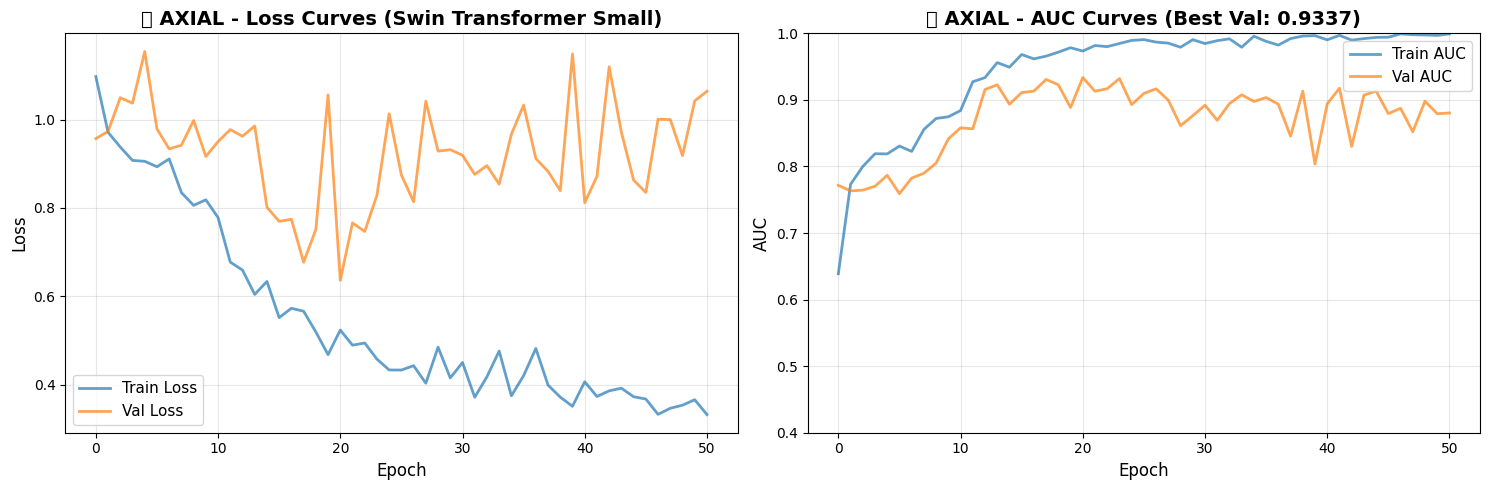

In [6]:
# Visualizar resultados del entrenamiento - AXIAL
if train_axial and history is not None:
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))

 # Gráfica 1: Training Loss vs Validation Loss
    axes[0].plot(history['train_loss'], label='Train Loss', linewidth=2, alpha=0.7)
    axes[0].plot(history['val_loss_objective'], label='Val Loss', linewidth=2, alpha=0.7)
    axes[0].set_xlabel('Epoch', fontsize=12)
    axes[0].set_ylabel('Loss', fontsize=12)
    axes[0].set_title(f' AXIAL - Loss Curves (Swin Transformer Small)', fontsize=14, fontweight='bold')
    axes[0].legend(fontsize=11)
    axes[0].grid(True, alpha=0.3)

 # Gráfica 2: Training AUC vs Validation AUC
    axes[1].plot(history['train_auc'], label='Train AUC', linewidth=2, alpha=0.7)
    axes[1].plot(history['val_auc'], label='Val AUC', linewidth=2, alpha=0.7)
    axes[1].set_xlabel('Epoch', fontsize=12)
    axes[1].set_ylabel('AUC', fontsize=12)
    axes[1].set_title(f' AXIAL - AUC Curves (Best Val: {best_auc:.4f})', fontsize=14, fontweight='bold')
    axes[1].legend(fontsize=11)
    axes[1].grid(True, alpha=0.3)
    axes[1].set_ylim([0.4, 1.0])

    plt.tight_layout()

 # Guardar figura
    plot_path = CHECKPOINT_DIR / f"training_curves_axial.png"
    plt.savefig(plot_path, dpi=300, bbox_inches='tight')
    print(f" Gráficas guardadas en: {plot_path}\n")
    plt.show()

## 6⃣ Ensemble Evaluation - Swin Transformer Small

In [7]:
# Cargar checkpoints de los 3 planos y generar predicciones
print(f"\n{'='*100}")
print(f" CARGANDO MODELOS PARA ENSEMBLE (Swin Transformer Small)")
print(f"{'='*100}\n")

# Load all test data
targets_test = []
indices_test = []
for plane in PLANES:
    csv_path = DATA_PATH / 'test-acl.csv'
    data_root = DATA_PATH / 'test'

    test_dataset = OptimizedMRNetDataset(
        csv_path=csv_path,
        data_root=data_root,
        plane=plane,
        indices_cache_path=SLICE_INDICES_DIR / f"test_{plane}_indices.json",
        augmentation_mode=None,
        transform=get_val_test_transform()
    )

    test_loader = DataLoader(
        test_dataset, batch_size=BATCH_SIZE, shuffle=False,
        num_workers=NUM_WORKERS, pin_memory=True
    )

 # Get targets (same for all planes)
    if plane == 'sagittal':
        for _, labels, _ in test_loader:
            targets_test.extend(labels.cpu().numpy().tolist())

# Convert to numpy
targets_test = np.array(targets_test)

print(f" Test targets loaded: {len(targets_test)} samples\n")

# Store predictions per plane
probs_per_plane_test = {}
probs_per_plane_val = {}

# Load models and generate predictions for each plane
for plane in PLANES:
    print(f"Processing {plane.upper()}...")

 # Load model
    model = SwinMultiSliceClassifier(
        num_classes=NUM_CLASSES,
        pretrained=False,
        pooling_mode=PLANE_CONFIG[plane].get('pooling_mode', 'attention'),
        dropout_input=0.3,
        dropout_dense=0.2
    )

    checkpoint_path = CHECKPOINT_DIR / f"best_{plane}_auc.pth"
    checkpoint = torch.load(checkpoint_path, map_location='cpu')
    model.load_state_dict(checkpoint['model_state_dict'])

    model = nn.DataParallel(model, device_ids=VIT_GPU_IDS)
    model = model.to(device)
    model.eval()

 # Generate predictions on validation
    val_csv_path = DATA_PATH / 'val-acl.csv'
    val_data_root = DATA_PATH / 'val'

    val_dataset = OptimizedMRNetDataset(
        csv_path=val_csv_path,
        data_root=val_data_root,
        plane=plane,
        indices_cache_path=SLICE_INDICES_DIR / f"val_{plane}_indices.json",
        augmentation_mode=None,
        transform=get_val_test_transform()
    )

    val_loader = DataLoader(
        val_dataset, batch_size=BATCH_SIZE, shuffle=False,
        num_workers=NUM_WORKERS, pin_memory=True
    )

 # Validation predictions
    val_probs = []
    with torch.no_grad():
        for inputs, _, _ in val_loader:
            inputs = inputs.to(device)
            logits, _ = model(inputs) if isinstance(model.module, SwinMultiSliceClassifier) else (model(inputs), None)
            probs = torch.sigmoid(logits).cpu().numpy()
            val_probs.extend(probs.flatten().tolist())

    probs_per_plane_val[plane] = np.array(val_probs)

 # Test predictions
    test_csv_path = DATA_PATH / 'test-acl.csv'
    test_data_root = DATA_PATH / 'test'

    test_dataset = OptimizedMRNetDataset(
        csv_path=test_csv_path,
        data_root=test_data_root,
        plane=plane,
        indices_cache_path=SLICE_INDICES_DIR / f"test_{plane}_indices.json",
        augmentation_mode=None,
        transform=get_val_test_transform()
    )

    test_loader = DataLoader(
        test_dataset, batch_size=BATCH_SIZE, shuffle=False,
        num_workers=NUM_WORKERS, pin_memory=True
    )

    test_probs = []
    with torch.no_grad():
        for inputs, _, _ in test_loader:
            inputs = inputs.to(device)
            logits, _ = model(inputs) if isinstance(model.module, SwinMultiSliceClassifier) else (model(inputs), None)
            probs = torch.sigmoid(logits).cpu().numpy()
            test_probs.extend(probs.flatten().tolist())

    probs_per_plane_test[plane] = np.array(test_probs)
    print(f" {plane}: Val={len(val_probs)}, Test={len(test_probs)}")

print(f"\n{'='*100}")
print(f" TODOS LOS MODELOS CARGADOS")
print(f"{'='*100}\n")


 CARGANDO MODELOS PARA ENSEMBLE (Swin Transformer Small)

 Dataset cargado: 187 casos
  Plane: sagittal
  Augmentation: None (usando transform directo)
  Índices cacheados: ../../data/slice_indices_final/test_sagittal_indices.json
 Dataset cargado: 187 casos
  Plane: coronal
  Augmentation: None (usando transform directo)
  Índices cacheados: ../../data/slice_indices_final/test_coronal_indices.json
 Dataset cargado: 187 casos
  Plane: axial
  Augmentation: None (usando transform directo)
  Índices cacheados: ../../data/slice_indices_final/test_axial_indices.json
 Test targets loaded: 187 samples

Processing SAGITTAL...
 Dataset cargado: 188 casos
  Plane: sagittal
  Augmentation: None (usando transform directo)
  Índices cacheados: ../../data/slice_indices_final/val_sagittal_indices.json
 Dataset cargado: 187 casos
  Plane: sagittal
  Augmentation: None (usando transform directo)
  Índices cacheados: ../../data/slice_indices_final/test_sagittal_indices.json
 sagittal: Val=188, Test=18

In [8]:
# Generar predicciones del ensamble
print(f"\n{'='*100}")
print(f" GENERANDO PREDICCIONES DEL ENSAMBLE")
print(f"{'='*100}\n")

# Load validation targets
val_csv_path = DATA_PATH / 'val-acl.csv'
val_dataset = pd.read_csv(val_csv_path, header=None, names=['case_id', 'acl'])
targets_val = val_dataset['acl'].values[:len(probs_per_plane_val['sagittal'])]

# Ensemble: average probabilities across planes
ensemble_probs_val = np.mean([probs_per_plane_val[plane] for plane in PLANES], axis=0)
ensemble_probs_test = np.mean([probs_per_plane_test[plane] for plane in PLANES], axis=0)

print(f" Validation ensemble:")
print(f"  Targets: {len(targets_val)}")
print(f"  Probs shape: {ensemble_probs_val.shape}")
print(f"  Probs range: [{ensemble_probs_val.min():.3f}, {ensemble_probs_val.max():.3f}]")

print(f"\n Test ensemble:")
print(f"  Targets: {len(targets_test)}")
print(f"  Probs shape: {ensemble_probs_test.shape}")
print(f"  Probs range: [{ensemble_probs_test.min():.3f}, {ensemble_probs_test.max():.3f}]")

# Validación AUC individual por plano
print(f"\n{'='*100}")
print(f" AUC POR PLANO (VALIDACIÓN)")
print(f"{'='*100}\n")

val_auc_per_plane = {}
for plane in PLANES:
    auc = roc_auc_score(targets_val, probs_per_plane_val[plane])
    val_auc_per_plane[plane] = auc
    print(f"  {plane.upper()}: {auc:.4f}")

val_auc_ensemble = roc_auc_score(targets_val, ensemble_probs_val)
print(f"  ENSEMBLE: {val_auc_ensemble:.4f} ")

# Test AUC individual por plano
print(f"\n{'='*100}")
print(f" AUC POR PLANO (TEST)")
print(f"{'='*100}\n")

test_auc_per_plane = {}
for plane in PLANES:
    auc = roc_auc_score(targets_test, probs_per_plane_test[plane])
    test_auc_per_plane[plane] = auc
    print(f"  {plane.upper()}: {auc:.4f}")

test_auc_ensemble = roc_auc_score(targets_test, ensemble_probs_test)
print(f"  ENSEMBLE: {test_auc_ensemble:.4f} \n")


 GENERANDO PREDICCIONES DEL ENSAMBLE

 Validation ensemble:
  Targets: 188
  Probs shape: (188,)
  Probs range: [0.117, 0.991]

 Test ensemble:
  Targets: 187
  Probs shape: (187,)
  Probs range: [0.120, 0.995]

 AUC POR PLANO (VALIDACIÓN)

  SAGITTAL: 0.8951
  CORONAL: 0.9172
  AXIAL: 0.9337
  ENSEMBLE: 0.9671

 AUC POR PLANO (TEST)

  SAGITTAL: 0.8702
  CORONAL: 0.9189
  AXIAL: 0.9181
  ENSEMBLE: 0.9356



In [9]:
# Calibración de umbral (Threshold Calibration)
def compute_metrics(probs, targets, threshold):
    """Compute classification metrics given a threshold"""
    preds = (probs >= threshold).astype(int)
    tp = np.sum((preds == 1) & (targets == 1))
    tn = np.sum((preds == 0) & (targets == 0))
    fp = np.sum((preds == 1) & (targets == 0))
    fn = np.sum((preds == 0) & (targets == 1))

    eps = 1e-8
    precision = tp / (tp + fp + eps)
    recall = tp / (tp + fn + eps)
    specificity = tn / (tn + fp + eps)
    f1 = 2 * (precision * recall) / (precision + recall + eps)
    youdens = recall + specificity - 1
    auc = roc_auc_score(targets, probs)

    return {
        'tp': int(tp), 'tn': int(tn), 'fp': int(fp), 'fn': int(fn),
        'precision': float(precision), 'recall': float(recall),
        'specificity': float(specificity), 'f1': float(f1),
        'youdens': float(youdens), 'auc': float(auc)
    }

print(f"\n{'='*100}")
print(f" CALIBRACIÓN DE UMBRAL (VALIDACIÓN)")
print(f"{'='*100}\n")

# Buscar umbral óptimo por diferentes criterios
thresholds = np.arange(0.1, 0.9, 0.01)
f1_scores = []
recall_scores = []
youdens_scores = []
precision_scores = []

for threshold in thresholds:
    metrics = compute_metrics(ensemble_probs_val, targets_val, threshold)
    f1_scores.append(metrics['f1'])
    recall_scores.append(metrics['recall'])
    youdens_scores.append(metrics['youdens'])
    precision_scores.append(metrics['precision'])

# Estrategia 1: MAX F1
best_threshold_f1 = thresholds[np.argmax(f1_scores)]
metrics_opt1 = compute_metrics(ensemble_probs_val, targets_val, best_threshold_f1)

# Estrategia 2: MAX RECALL con Precision >= 0.75 NUEVA ESTRATEGIA
valid_indices = np.where(np.array(precision_scores) >= 0.75)[0]
if len(valid_indices) > 0:
    max_recall_idx = valid_indices[np.argmax(np.array(recall_scores)[valid_indices])]
    best_threshold_recall_constrained = thresholds[max_recall_idx]
    metrics_opt2 = compute_metrics(ensemble_probs_val, targets_val, best_threshold_recall_constrained)
else:
 # Si no hay threshold con precision >= 0.75, usar el que tenga máxima precision
    best_threshold_recall_constrained = thresholds[np.argmax(precision_scores)]
    metrics_opt2 = compute_metrics(ensemble_probs_val, targets_val, best_threshold_recall_constrained)

# Estrategia 3: MAX YOUDENS
best_threshold_youdens = thresholds[np.argmax(youdens_scores)]
metrics_opt3 = compute_metrics(ensemble_probs_val, targets_val, best_threshold_youdens)

print(f"1⃣  MAX F1 (threshold={best_threshold_f1:.2f}):")
print(f"    F1: {metrics_opt1['f1']:.4f}, Precision: {metrics_opt1['precision']:.4f}, Recall: {metrics_opt1['recall']:.4f}")

print(f"\n2⃣  MAX RECALL + PRECISION >= 0.75 (threshold={best_threshold_recall_constrained:.2f}): ")
print(f"    F1: {metrics_opt2['f1']:.4f}, Precision: {metrics_opt2['precision']:.4f}, Recall: {metrics_opt2['recall']:.4f}")

print(f"\n3⃣  MAX YOUDENS (threshold={best_threshold_youdens:.2f}):")
print(f"    F1: {metrics_opt3['f1']:.4f}, Precision: {metrics_opt3['precision']:.4f}, Recall: {metrics_opt3['recall']:.4f}\n")


 CALIBRACIÓN DE UMBRAL (VALIDACIÓN)

1⃣  MAX F1 (threshold=0.61):
    F1: 0.8421, Precision: 0.8000, Recall: 0.8889

2⃣  MAX RECALL + PRECISION >= 0.75 (threshold=0.58):
    F1: 0.8205, Precision: 0.7619, Recall: 0.8889

3⃣  MAX YOUDENS (threshold=0.47):
    F1: 0.8293, Precision: 0.7391, Recall: 0.9444




 MATRICES DE CONFUSIÓN - VALIDACIÓN SET (con umbral calibrado)



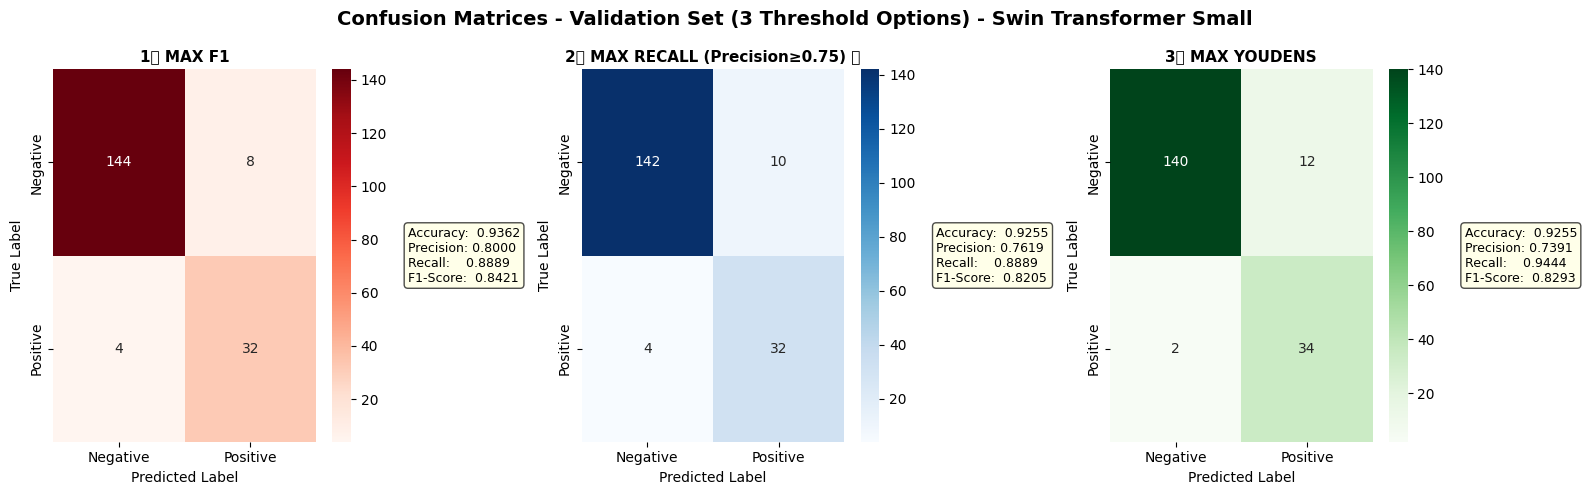

 Matrices de confusión (validación) generadas

 THRESHOLD SELECCIONADO: 0.58 (2⃣ MAX RECALL (Precision≥0.75) )



In [10]:
# MATRICES DE CONFUSIÓN - VALIDACIÓN (3 OPCIONES)
print(f"\n{'='*100}")
print(f" MATRICES DE CONFUSIÓN - VALIDACIÓN SET (con umbral calibrado)")
print(f"{'='*100}\n")

# Generar predicciones para cada opción EN VALIDACIÓN
preds_val_opt1 = (ensemble_probs_val >= best_threshold_f1).astype(int)
cm_val_opt1 = confusion_matrix(targets_val, preds_val_opt1)

preds_val_opt2 = (ensemble_probs_val >= best_threshold_recall_constrained).astype(int)
cm_val_opt2 = confusion_matrix(targets_val, preds_val_opt2)

preds_val_opt3 = (ensemble_probs_val >= best_threshold_youdens).astype(int)
cm_val_opt3 = confusion_matrix(targets_val, preds_val_opt3)

# Visualizar matrices
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Confusion Matrices - Validation Set (3 Threshold Options) - Swin Transformer Small', fontsize=14, fontweight='bold')

colors_opts = ['Reds', 'Blues', 'Greens']
titles = ['1⃣ MAX F1', '2⃣ MAX RECALL (Precision≥0.75) ', '3⃣ MAX YOUDENS']
cms_val = [cm_val_opt1, cm_val_opt2, cm_val_opt3]
metrics_val_opts = [metrics_opt1, metrics_opt2, metrics_opt3]

for idx, (ax, cm, color_map, title, metrics) in enumerate(zip(axes, cms_val, colors_opts, titles, metrics_val_opts)):
    sns.heatmap(cm, annot=True, fmt='d', cmap=color_map, ax=ax, cbar=True,
                xticklabels=['Negative', 'Positive'],
                yticklabels=['Negative', 'Positive'])
    ax.set_ylabel('True Label', fontsize=10)
    ax.set_xlabel('Predicted Label', fontsize=10)
    ax.set_title(title, fontsize=11, fontweight='bold')

 # Calcular accuracy
    acc = (metrics['tp'] + metrics['tn']) / (metrics['tp'] + metrics['tn'] + metrics['fp'] + metrics['fn'])
    metrics_text = f"""Accuracy:  {acc:.4f}
Precision: {metrics['precision']:.4f}
Recall:    {metrics['recall']:.4f}
F1-Score:  {metrics['f1']:.4f}"""
    ax.text(1.35, 0.5, metrics_text, fontsize=9, bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.7),
            transform=ax.transAxes, verticalalignment='center')

plt.tight_layout()
plt.show()

print(" Matrices de confusión (validación) generadas\n")

# Guardar best_threshold como el que elegimos (por defecto, Constrained Recall)
SELECTED_THRESHOLD = best_threshold_recall_constrained
SELECTED_OPTION = "2⃣ MAX RECALL (Precision≥0.75) "
print(f" THRESHOLD SELECCIONADO: {SELECTED_THRESHOLD:.2f} ({SELECTED_OPTION})\n")


 MATRICES DE CONFUSIÓN - TEST SET (con umbral calibrado)



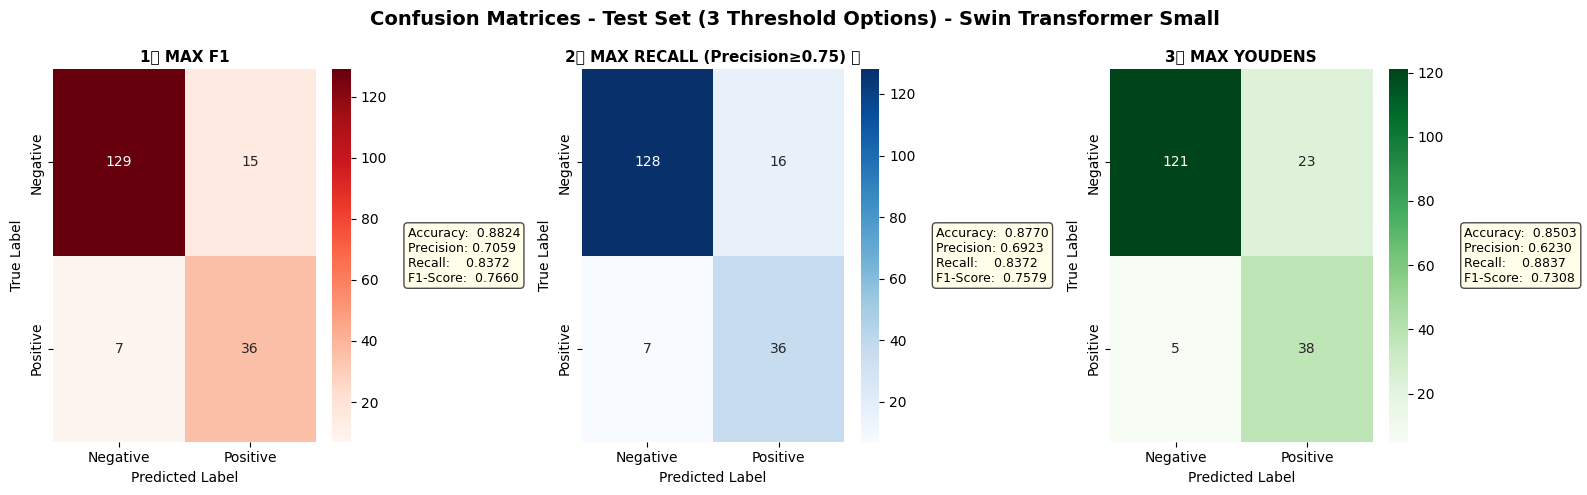

 Matrices de confusión (test) generadas



In [11]:
# MATRICES DE CONFUSIÓN - TEST (3 OPCIONES) - CON THRESHOLD CALIBRADO
print(f"\n{'='*100}")
print(f" MATRICES DE CONFUSIÓN - TEST SET (con umbral calibrado)")
print(f"{'='*100}\n")

# Generar predicciones para cada opción EN TEST
preds_test_opt1 = (ensemble_probs_test >= best_threshold_f1).astype(int)
cm_test_opt1 = confusion_matrix(targets_test, preds_test_opt1)

preds_test_opt2 = (ensemble_probs_test >= best_threshold_recall_constrained).astype(int)
cm_test_opt2 = confusion_matrix(targets_test, preds_test_opt2)

preds_test_opt3 = (ensemble_probs_test >= best_threshold_youdens).astype(int)
cm_test_opt3 = confusion_matrix(targets_test, preds_test_opt3)

# Calcular métricas en test
metrics_test_opt1 = compute_metrics(ensemble_probs_test, targets_test, best_threshold_f1)
metrics_test_opt2 = compute_metrics(ensemble_probs_test, targets_test, best_threshold_recall_constrained)
metrics_test_opt3 = compute_metrics(ensemble_probs_test, targets_test, best_threshold_youdens)

# Visualizar matrices
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Confusion Matrices - Test Set (3 Threshold Options) - Swin Transformer Small', fontsize=14, fontweight='bold')

cms_test = [cm_test_opt1, cm_test_opt2, cm_test_opt3]
metrics_test_opts = [metrics_test_opt1, metrics_test_opt2, metrics_test_opt3]

for idx, (ax, cm, color_map, title, metrics) in enumerate(zip(axes, cms_test, colors_opts, titles, metrics_test_opts)):
    sns.heatmap(cm, annot=True, fmt='d', cmap=color_map, ax=ax, cbar=True,
                xticklabels=['Negative', 'Positive'],
                yticklabels=['Negative', 'Positive'])
    ax.set_ylabel('True Label', fontsize=10)
    ax.set_xlabel('Predicted Label', fontsize=10)
    ax.set_title(title, fontsize=11, fontweight='bold')

 # Calcular accuracy
    acc = (metrics['tp'] + metrics['tn']) / (metrics['tp'] + metrics['tn'] + metrics['fp'] + metrics['fn'])
    metrics_text = f"""Accuracy:  {acc:.4f}
Precision: {metrics['precision']:.4f}
Recall:    {metrics['recall']:.4f}
F1-Score:  {metrics['f1']:.4f}"""
    ax.text(1.35, 0.5, metrics_text, fontsize=9, bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.7),
            transform=ax.transAxes, verticalalignment='center')

plt.tight_layout()
plt.show()

print(" Matrices de confusión (test) generadas\n")


 ROC CURVES - ENSEMBLE SWIN TRANSFORMER TINY



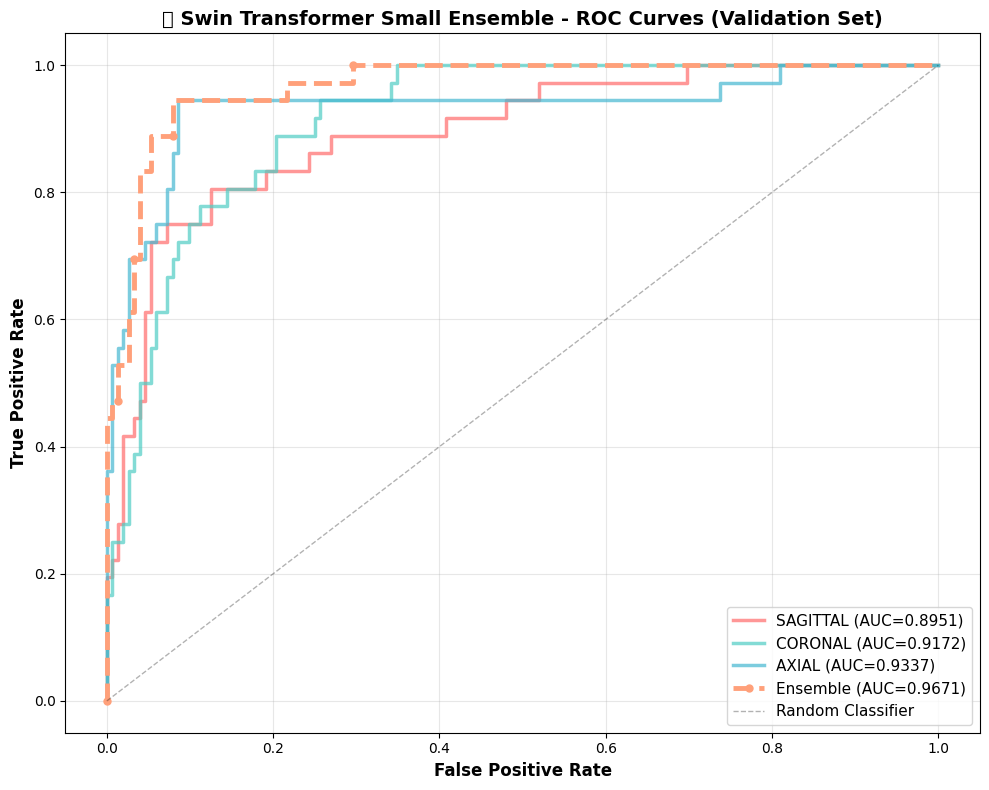

 ROC curves generadas


 RESUMEN COMPARATIVO: VALIDACIÓN vs TEST

                           Option Threshold Val_AUC Val_F1 Val_Recall Test_AUC Test_F1 Test_Recall
                       1⃣ MAX F1      0.61  0.9671 0.8421     0.8889   0.9356  0.7660      0.8372
2⃣ MAX RECALL (Precision≥0.75)       0.58  0.9671 0.8205     0.8889   0.9356  0.7579      0.8372
                  3⃣ MAX YOUDENS      0.47  0.9671 0.8293     0.9444   0.9356  0.7308      0.8837

 ENSAMBLE SWIN TRANSFORMER TINY COMPLETADO CON THRESHOLD CALIBRADO

 Resultados guardados en: ../../checkpoints/swin_tiny_baseline/ensemble_results_calibrated.json



: 

In [ ]:
# ROC CURVES Y RESUMEN FINAL
print(f"\n{'='*100}")
print(f" ROC CURVES - ENSEMBLE SWIN TRANSFORMER TINY")
print(f"{'='*100}\n")

# Crear figura con ROC curves
fig, ax = plt.subplots(figsize=(10, 8))

# ROC individual por plano
colors_planes = ['#FF6B6B', '#4ECDC4', '#45B7D1']
for i, plane in enumerate(PLANES):
    fpr, tpr, _ = roc_curve(targets_val, probs_per_plane_val[plane])
    plane_auc = roc_auc_score(targets_val, probs_per_plane_val[plane])
    ax.plot(fpr, tpr, linewidth=2.5, label=f'{plane.upper()} (AUC={plane_auc:.4f})', color=colors_planes[i], alpha=0.7)

# ROC Ensemble
fpr_ens, tpr_ens, _ = roc_curve(targets_val, ensemble_probs_val)
ax.plot(fpr_ens, tpr_ens, linewidth=3.5, label=f'Ensemble (AUC={val_auc_ensemble:.4f})',
        color='#FFA07A', linestyle='--', marker='o', markersize=5, markevery=5)

# Línea diagonal
ax.plot([0, 1], [0, 1], 'k--', linewidth=1, alpha=0.3, label='Random Classifier')

ax.set_xlabel('False Positive Rate', fontsize=12, fontweight='bold')
ax.set_ylabel('True Positive Rate', fontsize=12, fontweight='bold')
ax.set_title(' Swin Transformer Small Ensemble - ROC Curves (Validation Set)', fontsize=14, fontweight='bold')
ax.legend(fontsize=11, loc='lower right')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(" ROC curves generadas\n")

# TABLA COMPARATIVA: VALIDACIÓN vs TEST
print(f"\n{'='*100}")
print(f" RESUMEN COMPARATIVO: VALIDACIÓN vs TEST")
print(f"{'='*100}\n")

summary_data = []

# Opción 1
acc_val_opt1 = (metrics_opt1['tp'] + metrics_opt1['tn']) / (metrics_opt1['tp'] + metrics_opt1['tn'] + metrics_opt1['fp'] + metrics_opt1['fn'])
acc_test_opt1 = (metrics_test_opt1['tp'] + metrics_test_opt1['tn']) / (metrics_test_opt1['tp'] + metrics_test_opt1['tn'] + metrics_test_opt1['fp'] + metrics_test_opt1['fn'])

summary_data.append({
    'Option': '1⃣ MAX F1',
    'Threshold': f'{best_threshold_f1:.2f}',
    'Val_AUC': f"{metrics_opt1['auc']:.4f}",
    'Val_F1': f"{metrics_opt1['f1']:.4f}",
    'Val_Recall': f"{metrics_opt1['recall']:.4f}",
    'Test_AUC': f"{metrics_test_opt1['auc']:.4f}",
    'Test_F1': f"{metrics_test_opt1['f1']:.4f}",
    'Test_Recall': f"{metrics_test_opt1['recall']:.4f}"
})

# Opción 2 - NUEVA ESTRATEGIA SELECCIONADA
acc_val_opt2 = (metrics_opt2['tp'] + metrics_opt2['tn']) / (metrics_opt2['tp'] + metrics_opt2['tn'] + metrics_opt2['fp'] + metrics_opt2['fn'])
acc_test_opt2 = (metrics_test_opt2['tp'] + metrics_test_opt2['tn']) / (metrics_test_opt2['tp'] + metrics_test_opt2['tn'] + metrics_test_opt2['fp'] + metrics_test_opt2['fn'])

summary_data.append({
    'Option': '2⃣ MAX RECALL (Precision≥0.75) ',
    'Threshold': f'{best_threshold_recall_constrained:.2f}',
    'Val_AUC': f"{metrics_opt2['auc']:.4f}",
    'Val_F1': f"{metrics_opt2['f1']:.4f}",
    'Val_Recall': f"{metrics_opt2['recall']:.4f}",
    'Test_AUC': f"{metrics_test_opt2['auc']:.4f}",
    'Test_F1': f"{metrics_test_opt2['f1']:.4f}",
    'Test_Recall': f"{metrics_test_opt2['recall']:.4f}"
})

# Opción 3
acc_val_opt3 = (metrics_opt3['tp'] + metrics_opt3['tn']) / (metrics_opt3['tp'] + metrics_opt3['tn'] + metrics_opt3['fp'] + metrics_opt3['fn'])
acc_test_opt3 = (metrics_test_opt3['tp'] + metrics_test_opt3['tn']) / (metrics_test_opt3['tp'] + metrics_test_opt3['tn'] + metrics_test_opt3['fp'] + metrics_test_opt3['fn'])

summary_data.append({
    'Option': '3⃣ MAX YOUDENS',
    'Threshold': f'{best_threshold_youdens:.2f}',
    'Val_AUC': f"{metrics_opt3['auc']:.4f}",
    'Val_F1': f"{metrics_opt3['f1']:.4f}",
    'Val_Recall': f"{metrics_opt3['recall']:.4f}",
    'Test_AUC': f"{metrics_test_opt3['auc']:.4f}",
    'Test_F1': f"{metrics_test_opt3['f1']:.4f}",
    'Test_Recall': f"{metrics_test_opt3['recall']:.4f}"
})

df_summary = pd.DataFrame(summary_data)
print(df_summary.to_string(index=False))

print(f"\n{'='*100}")
print(f" ENSAMBLE SWIN TRANSFORMER TINY COMPLETADO CON THRESHOLD CALIBRADO")
print(f"{'='*100}\n")

# Guardar resultados en JSON usando OPTION 2 (MAX RECALL con Precision >= 0.75)
results_summary = {
    'model': 'Swin Transformer Small Ensemble (with Threshold Calibration, ImageNet-1K pre-trained)',
    'selected_threshold': float(SELECTED_THRESHOLD),
    'selected_option': str(SELECTED_OPTION),
    'threshold_strategy': 'MAX RECALL with Precision >= 0.75',
    'validation': {
        'auc': float(metrics_opt2['auc']),
        'f1': float(metrics_opt2['f1']),
        'precision': float(metrics_opt2['precision']),
        'recall': float(metrics_opt2['recall']),
        'specificity': float(metrics_opt2['specificity']),
        'youdens': float(metrics_opt2['youdens'])
    },
    'test': {
        'auc': float(metrics_test_opt2['auc']),
        'f1': float(metrics_test_opt2['f1']),
        'precision': float(metrics_test_opt2['precision']),
        'recall': float(metrics_test_opt2['recall']),
        'specificity': float(metrics_test_opt2['specificity']),
        'youdens': float(metrics_test_opt2['youdens'])
    },
    'planes': {}
}

for plane in PLANES:
    val_auc = roc_auc_score(targets_val, probs_per_plane_val[plane])
    test_auc = roc_auc_score(targets_test, probs_per_plane_test[plane])
    results_summary['planes'][plane] = {
        'val_auc': float(val_auc),
        'test_auc': float(test_auc)
    }

results_json_path = CHECKPOINT_DIR / "ensemble_results_calibrated.json"
with open(results_json_path, 'w') as f:
    json.dump(results_summary, f, indent=2)

print(f" Resultados guardados en: {results_json_path}\n")